## Explaining Object Recognition in ImageNet Dataset

In [1]:
import cv2
import numpy as np
import torch
import torchvision
from torchvision import models
import torch.nn.functional as F
# from torchvision import transforms
import matplotlib.pyplot as plt

# from skimage.filters import gaussian
import importlib
import shap_bpt_setup as sbs

In [2]:
device = sbs.get_device()
print(device)

cuda


In [3]:
import timm

model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)    # Resnet50_Weights 
# model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)    # Resnet50_Weights 
# model = torchvision.models.vit_b_16(weights='IMAGENET1K_V1')                     # vit_b_16_Weights    
# model = models.vgg16(pretrained=True)
# model = timm.create_model('vit_base_patch16_224', pretrained=True)
# model = timm.create_model('swin_base_patch4_window7_224', pretrained=True)

model = model.to('cuda').eval()

##########################################################
def f(x):
    model = model.to(x.device)
    return F.softmax(model(x), dim=1).cpu().detach().numpy()

In [4]:
class_names = sbs.get_imagenet_classes()

Number of ImageNet classes: 1000


In [5]:
importlib.reload(sbs)

<module 'shap_bpt_setup' from 'e:\\PHD\\datacloud_data\\repos\\my_git\\papers_repo\\shap_bpt_tests\\minimal_notebooks\\shap_bpt_setup.py'>

In [6]:
image_to_explain,image_to_explain_tensor,background_image_set,background_tensors = sbs.load_image(fname='ILSVRC2012_val_00000774', bg_type='gray', device=device)

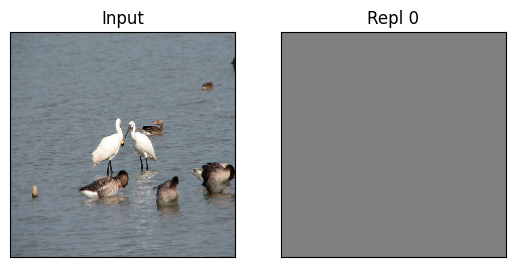

In [7]:
fig,ax = plt.subplots(1,1+len(background_image_set))
ax[0].imshow(image_to_explain); ax[0].set_title('Input'); ax[0].set_xticks([]); ax[0].set_yticks([])
for i,img in enumerate(background_image_set):
    ax[i+1].imshow(img.astype(np.uint8)); ax[i+1].set_title(f'Repl {i}'); ax[i+1].set_xticks([]); ax[i+1].set_yticks([])
plt.show()

In [8]:
importlib.reload(sbs)
predicted_fS,predicted_cls, f_S, predicted_f0, f_0 = sbs.load_image_to_explain(f,model,fname='ILSVRC2012_val_00000774' ,bg_type='gray')
print(class_names[predicted_cls],f_S,f_0)

UnboundLocalError: local variable 'model' referenced before assignment

In [9]:
import shap_bpt
#---------------------------------------------------------------------
num_explained_classes = 4
batch_size = 4
num_samples = 1000
#---------------------------------------------------------------------
explainer = shap_bpt.Explainer(sbs.f_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)

NameError: name 'background_tensors' is not defined

In [10]:
shap_values_bpt = explainer.explain_instance(num_samples, method='BPT',batch_size=batch_size)

NameError: name 'explainer' is not defined

In [34]:
shap_values_aa = explainer.explain_instance(num_samples, method='AA', batch_size=batch_size)

  0%|          | 0/1000 [00:00<?, ?it/s]

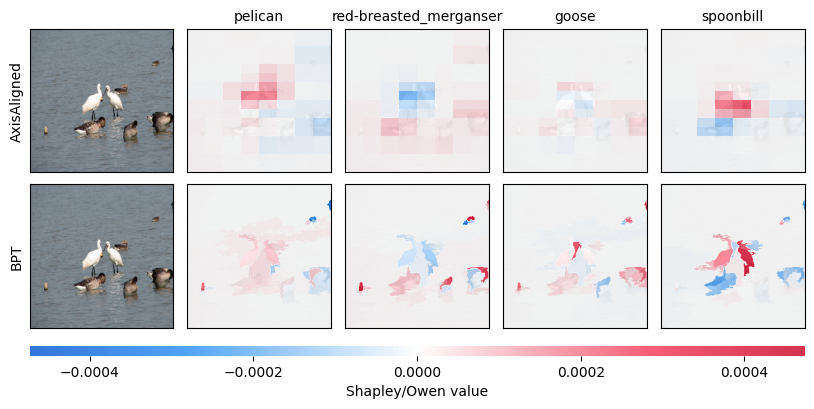

In [35]:
shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt],class_names, names=['AxisAligned','BPT'])

In [39]:
shap_bpt_tests.saliency_to_auc(f_masked, shap_values_bpt[0], f_S, f_0, predicted_cls, batch_size=4, method='del', num_samples=101, rule='trapezoid')
# heatmap, f_S, f_0, predicted_cls, batch_size=4, method='del', num_samples=101, rule='trapezoid'

TypeError: saliency_to_auc() got multiple values for argument 'batch_size'